- A hospital treats hundreds or thousands of patients. Right now, without any grouping, hospital staff basically has two bad options:

   - Treat everyone the same — same follow-up schedule, same level of monitoring, same resources — even though patients are wildly different (a healthy 25-year-old who came in once vs. an 80-year-old with 5 chronic conditions who's readmitted every month)
Manually review every single patient's chart to decide who needs extra attention — which doesn't scale once you have thousands of patients

Neither option works well. That's the actual pain point.

- Why this costs real money and real outcomes

   - Here's a fact from real healthcare research: a small fraction of patients (often around 2-5%) end up responsible for a huge chunk of total hospital costs — because they're readmitted repeatedly, need complex ongoing care, or have multiple conditions at once. If a hospital could identify that small high-need group early, they could assign them a dedicated care coordinator, follow up proactively, and prevent expensive emergency readmissions — instead of finding out too late.

  - But nobody walks in the door with a label saying "I am a high-cost, high-risk patient." That has to be discovered from their data (age, number of visits, length of stay, existing conditions, etc.) — which is precisely what K-Means is for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Hospital_data_completed.csv')

In [3]:
df.sample(10)

,Patient_ID,Age,Gender,Blood_Type,Chronic_Condition,BMI,Annual_Visits,Avg_Stay_Duration,Total_Spending,Insurance_Type
60,P10061,45.0,Male,A-,1,43.79,8,2,1237.9,Public
72,P10073,45.0,Male,A+,0,46.65,1,2,916.5,Public
0,P10001,45.0,Male,A+,0,20.00,3,2,750.0,NaN
21,P10022,45.0,Female,B-,2,20.00,3,3,950.0,Private
89,P10090,30.0,Female,B+,1,50.93,1,4,1359.3,Private
80,P10081,30.0,Male,A+,0,48.65,4,1,886.5,NaN
87,P10088,45.0,Female,AB-,4,50.36,4,3,1303.6,Private
46,P10047,60.0,Male,AB+,0,40.36,8,7,2203.6,Public
2,P10003,30.0,Male,O+,3,16.00,1,1,410.0,NaN
101,P10102,30.0,Female,B-,2,53.79,4,4,1537.9,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         109 non-null    object 
 1   Age                109 non-null    float64
 2   Gender             109 non-null    object 
 3   Blood_Type         109 non-null    object 
 4   Chronic_Condition  109 non-null    int64  
 5   BMI                109 non-null    float64
 6   Annual_Visits      109 non-null    int64  
 7   Avg_Stay_Duration  109 non-null    int64  
 8   Total_Spending     109 non-null    float64
 9   Insurance_Type     72 non-null     object 
dtypes: float64(3), int64(3), object(4)
memory usage: 8.6+ KB


In [5]:
df.describe()

,Age,Chronic_Condition,BMI,Annual_Visits,Avg_Stay_Duration,Total_Spending
count,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000
mean,45.000000,1.357798,39.078991,3.981651,3.651376,1320.147706
std,12.247449,1.404510,11.143315,2.384291,1.978477,439.818492
min,30.000000,0.000000,13.600000,1.000000,1.000000,410.000000
25%,30.000000,0.000000,32.930000,1.000000,2.000000,969.300000
50%,45.000000,1.000000,40.650000,4.000000,3.000000,1303.600000
75%,60.000000,2.000000,48.080000,6.000000,5.000000,1593.600000
max,60.000000,4.000000,55.500000,8.000000,7.000000,2306.500000


In [6]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Blood_Type,0
Chronic_Condition,0
BMI,0
Annual_Visits,0
Avg_Stay_Duration,0
Total_Spending,0
Insurance_Type,37


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Impute missing values
df['Insurance_Type'] = df['Insurance_Type'].fillna('None')

#EDA

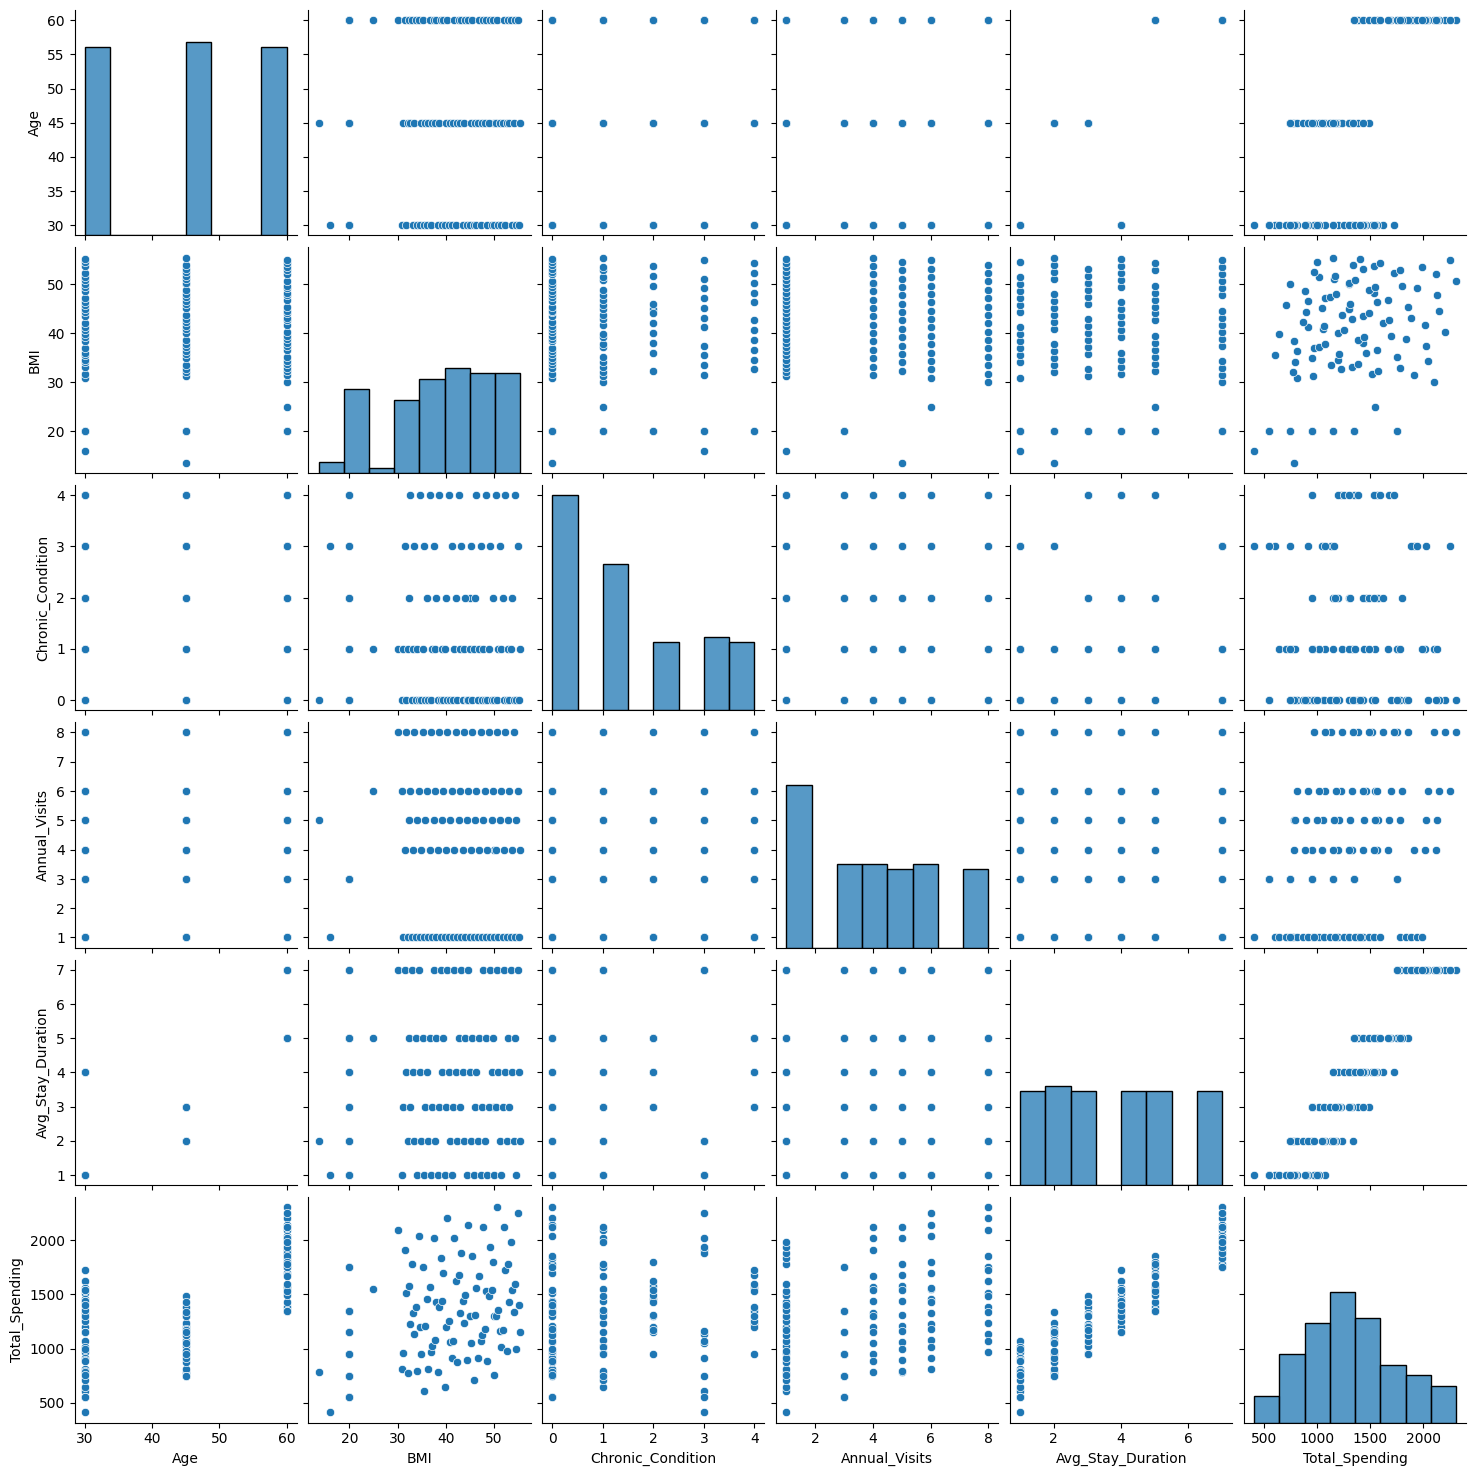

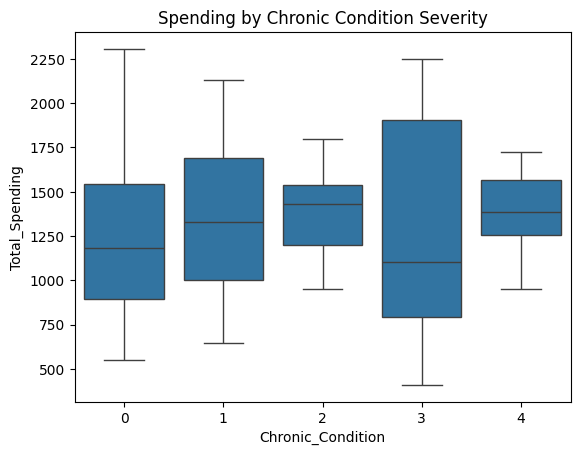

In [9]:
# Pairplot to explore distributions and relationships across key numerical variables
sns.pairplot(df[['Age', 'BMI', 'Chronic_Condition', 'Annual_Visits', 'Avg_Stay_Duration', 'Total_Spending']])
plt.show()

# Spending by Chronic Condition Severity
sns.boxplot(data=df, x='Chronic_Condition', y='Total_Spending')
plt.title('Spending by Chronic Condition Severity')
plt.show()

- Hypothesis 1 (Resource Drivers): Avg_Stay_Duration and Annual_Visits are the primary drivers of Total_Spending. K-Means will likely form a cluster around high-utilization/high-cost patients based heavily on these three variables.

- Hypothesis 2 (Demographic Impact): Because Age only has three discrete values (30, 45, 60), it acts more like a categorical filter than a continuous scale. Standardizing Age will group people strictly into three discrete tiers.
- Severity alone does not drive cost in this dataset. A patient with severity 0 can end up costing just as much as (or more than) a patient with severity 4.

This is why clustering needs multiple features together (Age, Annual_Visits, Avg_Stay_Duration, Total_Spending) rather than relying on Chronic_Condition alone to spot high-cost patients.

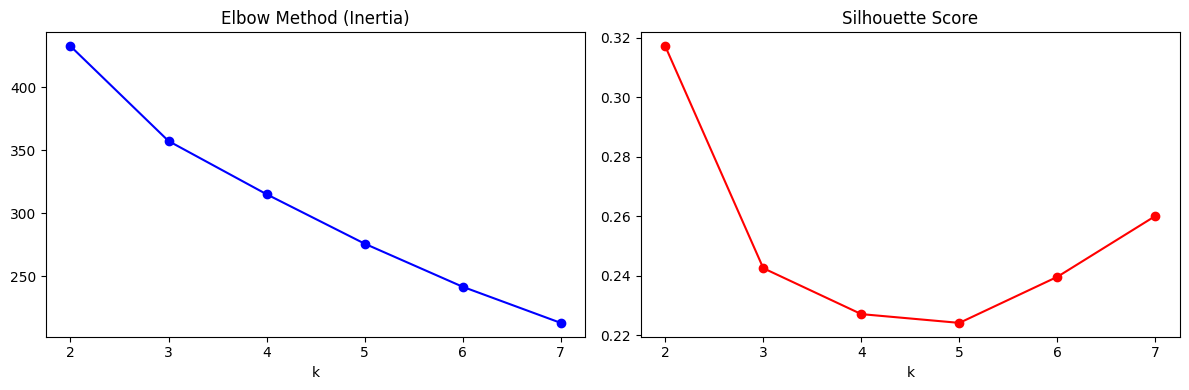

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Select features
features = ['Age', 'Chronic_Condition', 'BMI', 'Annual_Visits', 'Avg_Stay_Duration', 'Total_Spending']
X = df[features]

# 2. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Compute Inertia & Silhouette Scores
inertia = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 4. Plot Elbow and Silhouette side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_range, inertia, 'bo-')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('k')

ax[1].plot(k_range, silhouette_scores, 'ro-')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('k')

plt.tight_layout()
plt.show()

In [11]:
# 1. Fit K=2 and K=3 on your already-scaled data (X_scaled)
from sklearn.cluster import KMeans

kmeans_k2 = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
labels_k2 = kmeans_k2.fit_predict(X_scaled)

kmeans_k3 = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels_k3 = kmeans_k3.fit_predict(X_scaled)

# 2. Attach both label sets to your ORIGINAL (unscaled) dataframe
df['cluster_k2'] = labels_k2
df['cluster_k3'] = labels_k3

In [12]:
# 3. Profile K=2 — pick the columns that matter for the hospital story
profile_cols = ['Age', 'Chronic_Condition', 'BMI', 'Annual_Visits', 'Avg_Stay_Duration', 'Total_Spending']

print("=== K=2 Profile ===")
print(df.groupby('cluster_k2')[profile_cols].mean().round(1))
print(df['cluster_k2'].value_counts())

=== K=2 Profile ===
             Age  Chronic_Condition   BMI  Annual_Visits  Avg_Stay_Duration  \
cluster_k2                                                                    
0           60.0                1.5  39.1            4.1                6.0   
1           37.6                1.3  39.1            3.9                2.5   

            Total_Spending  
cluster_k2                  
0                   1794.1  
1                   1086.4  
cluster_k2
1    73
0    36
Name: count, dtype: int64


In [13]:
# 4. Profile K=3
print("=== K=3 Profile ===")
print(df.groupby('cluster_k3')[profile_cols].mean().round(1))
print(df['cluster_k3'].value_counts())

=== K=3 Profile ===
             Age  Chronic_Condition   BMI  Annual_Visits  Avg_Stay_Duration  \
cluster_k3                                                                    
0           37.1                1.1  33.8            2.2                2.4   
1           60.0                1.5  39.1            4.1                6.0   
2           38.1                1.5  44.8            5.9                2.6   

            Total_Spending  
cluster_k3                  
0                    924.5  
1                   1794.1  
2                   1262.3  
cluster_k3
0    38
1    36
2    35
Name: count, dtype: int64


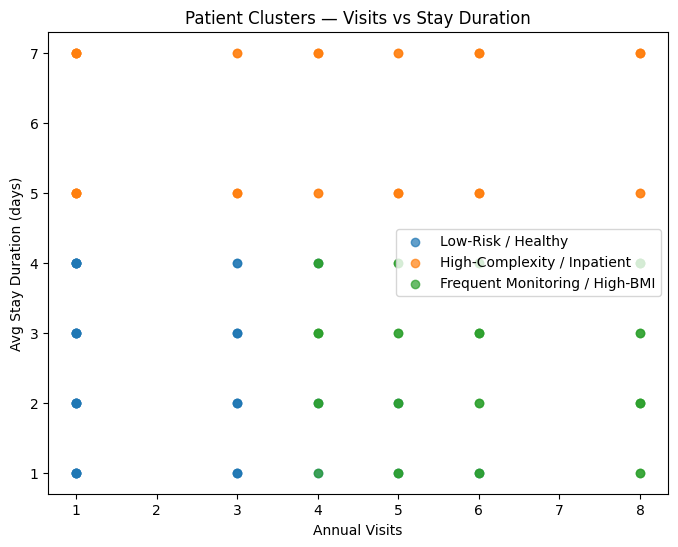

In [14]:
import matplotlib.pyplot as plt

# 1. Give the clusters real names for readable plots
persona_map = {
    0: "Low-Risk / Healthy",
    1: "High-Complexity / Inpatient",
    2: "Frequent Monitoring / High-BMI"
}
df['persona'] = df['cluster_k3'].map(persona_map)

# 2. Direct scatter — Annual Visits vs Avg Stay Duration
# (these two features best separate your 3 personas based on the profile table)
plt.figure(figsize=(8,6))
for persona in df['persona'].unique():
    subset = df[df['persona'] == persona]
    plt.scatter(subset['Annual_Visits'], subset['Avg_Stay_Duration'], label=persona, alpha=0.7)

plt.xlabel('Annual Visits')
plt.ylabel('Avg Stay Duration (days)')
plt.title('Patient Clusters — Visits vs Stay Duration')
plt.legend()
plt.show()

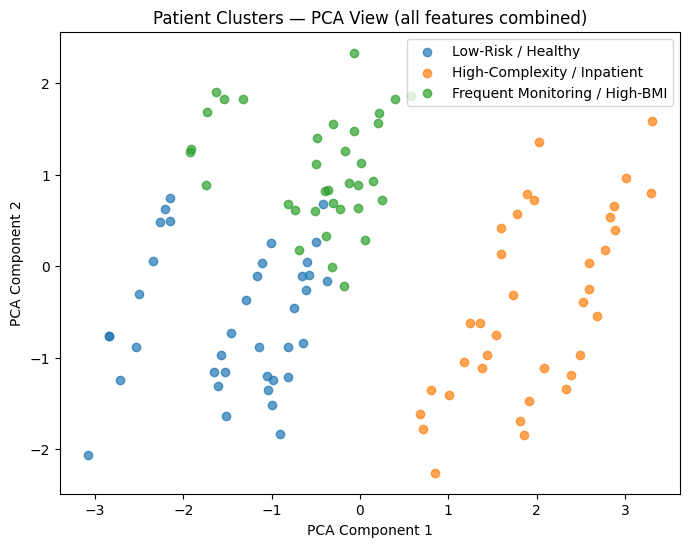

Variance explained by these 2 components: 63.0%


In [15]:
# 3. PCA scatter — captures ALL clustering features in one 2D view
# Useful here because you clustered on more than 2 features (unlike the mall project)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)   # X_scaled = the same data you clustered on

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
for persona in df['persona'].unique():
    subset = df[df['persona'] == persona]
    plt.scatter(subset['pca1'], subset['pca2'], label=persona, alpha=0.7)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Patient Clusters — PCA View (all features combined)')
plt.legend()
plt.show()

print(f"Variance explained by these 2 components: {pca.explained_variance_ratio_.sum():.1%}")